**Exploração Inicial dos Dados**

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [44]:
from google.colab import files

print('Selecione o arquivo raw_data.csv...')
uploaded = files.upload()

df = pd.read_csv('raw_data.csv')

print(f'Arquivo carregado!')
print(f'Total de registros: {len(df)}')
print(f'Total de colunas: {len(df.columns)}')
print(f'Colunas: {list(df.columns)}')

Selecione o arquivo raw_data.csv...


Saving raw_data.csv to raw_data (2).csv
Arquivo carregado!
Total de registros: 99999
Total de colunas: 6
Colunas: ['id', 'name', 'email', 'date_of_birth', 'signup_date', 'subscription_status']


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df.head(10)

,id,name,email,date_of_birth,signup_date,subscription_status
0,1,John Doe,john.doe@example.com,1985-01-15,2020-11-01,active
1,2,Jane Smith,jane.smith@example.com,1990-05-22,2019-06-17,active
2,3,Bob Johnson,bob.johnson@example,1977-03-30,2018-12-12,inactive
3,4,Alice Brown,alice.brown@example.com,1982-08-09,2021-01-05,active
4,5,Charlie Black,charlie.black@example.com,1988-11-23,NaN,inactive
5,6,Cassandra Bonilla,NaN,1990-06-07,2020-06-17,active
6,7,Alyssa Lee,NaN,1938-09-29,2020-10-18,inactive
7,8,Hannah Brown,heather75@example.net,1952-08-20,2024-02-16,inactive
8,9,James Thomas,NaN,2002-06-15,2020-02-10,inactive
9,10,James Snyder,natalie62example.org,NaN,2021-05-29,active


In [47]:
df.tail(5)

,id,name,email,date_of_birth,signup_date,subscription_status
99994,99995,Alexandria Garrett,grantangelaexample.net,1952-11-01,2020-10-28,active
99995,99996,NaN,patricia53example.net,NaN,2021-02-12,active
99996,99997,NaN,johnsonjohn@example.org,1943-04-08,2022-05-21,active
99997,99998,Steven Brady Jr.,NaN,2006-03-27,2024-03-11,active
99998,99999,Jennifer Calderon,victoria89@example.com,1985-04-11,2023-11-10,inactive


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   99999 non-null  int64 
 1   name                 75113 non-null  object
 2   email                74953 non-null  object
 3   date_of_birth        74828 non-null  object
 4   signup_date          99998 non-null  object
 5   subscription_status  99999 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.6+ MB


In [49]:
df.describe(include='all')

,id,name,email,date_of_birth,signup_date,subscription_status
count,99999.000000,75113,74953,74828,99998,99999
unique,NaN,56765,69914,25049,1617,2
top,NaN,Michael Smith,wsmithexample.net,1959-04-16,2022-06-01,inactive
freq,NaN,36,7,13,99,50081
mean,50000.000000,NaN,NaN,NaN,NaN,NaN
std,28867.369122,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,25000.500000,NaN,NaN,NaN,NaN,NaN
50%,50000.000000,NaN,NaN,NaN,NaN,NaN
75%,74999.500000,NaN,NaN,NaN,NaN,NaN


In [50]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)

resumo = pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
print('=== Valores Nulos por Coluna ===')
print(resumo[resumo['Nulos'] > 0])

=== Valores Nulos por Coluna ===
               Nulos  % Nulos
name           24886    24.89
email          25046    25.05
date_of_birth  25171    25.17
signup_date        1     0.00


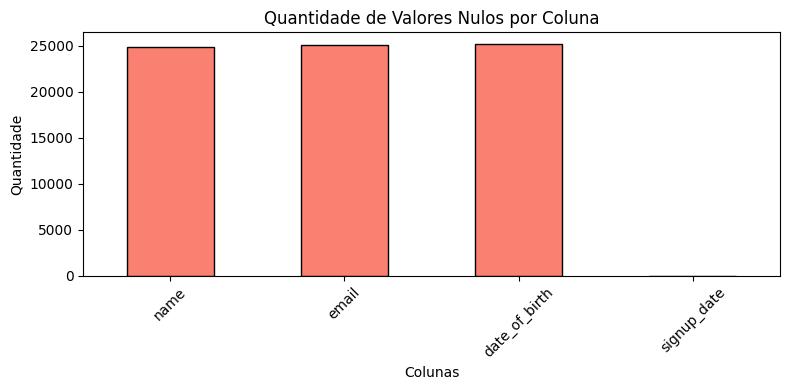

In [51]:
nulos_filtrado = nulos[nulos > 0]

if len(nulos_filtrado) > 0:
    plt.figure(figsize=(8, 4))
    nulos_filtrado.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Quantidade de Valores Nulos por Coluna')
    plt.xlabel('Colunas')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum valor nulo encontrado!')

In [52]:
import re

if 'email' in df.columns:
    invalidos = df[~df['email'].astype(str).str.contains('@', na=False)]
    print(f'Emails sem @: {len(invalidos)}')
    if len(invalidos) > 0:
        print('\nExemplos:')
        print(invalidos['email'].head(10).to_list())

Emails sem @: 62600

Exemplos:
[nan, nan, nan, 'natalie62example.org', 'williamscharlesexample.net', nan, 'beckermichaelexample.net', nan, nan, 'wrightlisaexample.net']


In [53]:
if 'date_of_birth' in df.columns:
    print('Amostras de date_of_birth:')
    print(df['date_of_birth'].dropna().head(10).to_list())

    convertidas = pd.to_datetime(df['date_of_birth'], errors='coerce')
    print(f'\nDatas inválidas: {convertidas.isna().sum()}')

Amostras de date_of_birth:
['1985-01-15', '1990-05-22', '1977-03-30', '1982-08-09', '1988-11-23', '1990-06-07', '1938-09-29', '1952-08-20', '2002-06-15', '1942-08-20']

Datas inválidas: 25171


In [54]:
if 'subscription_status' in df.columns:
    print('Contagem de subscription_status:')
    print(df['subscription_status'].value_counts())
    print('\nValores únicos brutos:')
    print(df['subscription_status'].unique())

Contagem de subscription_status:
subscription_status
inactive    50081
active      49918
Name: count, dtype: int64

Valores únicos brutos:
['active' 'inactive']


In [55]:
duplicatas = df.duplicated().sum()
print(f'Registros duplicados: {duplicatas}')

Registros duplicados: 0


In [57]:
print("""
=== O QUE PRECISA SER TRATADO ===

Problema                                  | Camada
------------------------------------------|--------
Registros com campos nulos                | Prata
Emails sem o caractere '@'                | Prata
Datas de nascimento mal formatadas        | Prata
Calcular a idade dos usuários             | Prata
Agrupar por faixa etária e status         | Ouro
""")


=== O QUE PRECISA SER TRATADO ===

Problema                                  | Camada
------------------------------------------|--------
Registros com campos nulos                | Prata
Emails sem o caractere '@'                | Prata
Datas de nascimento mal formatadas        | Prata
Calcular a idade dos usuários             | Prata
Agrupar por faixa etária e status         | Ouro



**Camada Bronze**

In [58]:
import pandas as pd
import os

BASE_PATH   = 'data'
BRONZE_PATH = os.path.join(BASE_PATH, 'bronze')
RAW_FILE    = os.path.join(BASE_PATH, 'raw_data.csv')

os.makedirs(BRONZE_PATH, exist_ok=True)
print(f'Pasta Bronze criada: {BRONZE_PATH}')
print(f'Arquivo de origem  : {RAW_FILE}')

Pasta Bronze criada: data/bronze
Arquivo de origem  : data/raw_data.csv


In [59]:
def upload_raw_data_to_bronze(raw_file=RAW_FILE, bronze_path=BRONZE_PATH):
    """
    Carrega o CSV bruto e salva na camada Bronze sem nenhuma alteração.
    Essa função é chamada como Task pelo Airflow.
    """
    if not os.path.exists(raw_file):
        raise FileNotFoundError(f'Arquivo não encontrado: {raw_file}')

    df = pd.read_csv(raw_file)

    print(f' Arquivo carregado!')
    print(f'   Registros : {len(df)}')
    print(f'   Colunas   : {list(df.columns)}')

    output = os.path.join(bronze_path, 'raw_data.csv')
    df.to_csv(output, index=False)

    print(f'\n Salvo na camada Bronze: {output}')
    return df

print('Função definida!')

Função definida!


In [60]:
import shutil

def upload_raw_data_to_bronze(raw_file='raw_data.csv', bronze_path='data/bronze'):
    """
    Carrega o CSV bruto e salva na camada Bronze sem nenhuma alteração.
    Essa função é chamada como Task pelo Airflow.
    """
    os.makedirs(bronze_path, exist_ok=True)

    if not os.path.exists(raw_file):
        raise FileNotFoundError(f'Arquivo não encontrado: {raw_file}')

    df = pd.read_csv(raw_file)

    print(f' Arquivo carregado!')
    print(f'   Registros : {len(df)}')
    print(f'   Colunas   : {list(df.columns)}')

    output = os.path.join(bronze_path, 'raw_data.csv')
    df.to_csv(output, index=False)

    print(f'\n Salvo na camada Bronze: {output}')
    return df

print('Função definida!')

Função definida!


In [62]:
df_bronze = upload_raw_data_to_bronze()

 Arquivo carregado!
   Registros : 99999
   Colunas   : ['id', 'name', 'email', 'date_of_birth', 'signup_date', 'subscription_status']

 Salvo na camada Bronze: data/bronze/raw_data.csv


In [63]:
df_bronze.head()

,id,name,email,date_of_birth,signup_date,subscription_status
0,1,John Doe,john.doe@example.com,1985-01-15,2020-11-01,active
1,2,Jane Smith,jane.smith@example.com,1990-05-22,2019-06-17,active
2,3,Bob Johnson,bob.johnson@example,1977-03-30,2018-12-12,inactive
3,4,Alice Brown,alice.brown@example.com,1982-08-09,2021-01-05,active
4,5,Charlie Black,charlie.black@example.com,1988-11-23,NaN,inactive


In [64]:
df_bronze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   99999 non-null  int64 
 1   name                 75113 non-null  object
 2   email                74953 non-null  object
 3   date_of_birth        74828 non-null  object
 4   signup_date          99998 non-null  object
 5   subscription_status  99999 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.6+ MB


In [66]:
bronze_file = os.path.join(BRONZE_PATH, 'raw_data.csv')
df_original = pd.read_csv('raw_data.csv')
df_salvo    = pd.read_csv(bronze_file)

print(f'Registros original : {len(df_original)}')
print(f'Registros Bronze   : {len(df_salvo)}')

if df_original.equals(df_salvo):
    print('\n Bronze idêntico ao original — nenhuma alteração foi feita.')
else:
    print('\n  Diferença detectada entre original e Bronze!')

Registros original : 99999
Registros Bronze   : 99999

 Bronze idêntico ao original — nenhuma alteração foi feita.


**Camada Prata**

In [67]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt

BASE_PATH   = '.'
BRONZE_PATH = 'data/bronze'
PRATA_PATH  = 'data/prata'

os.makedirs(PRATA_PATH, exist_ok=True)
print('Configuração OK!')

Configuração OK!


In [68]:
df = pd.read_csv(os.path.join(BRONZE_PATH, 'raw_data.csv'))
total_inicial = len(df)

print(f'Registros carregados da Bronze: {total_inicial}')
print(f'Colunas: {list(df.columns)}')
print(f'\nNulos antes da limpeza:')
print(df.isnull().sum())

Registros carregados da Bronze: 99999
Colunas: ['id', 'name', 'email', 'date_of_birth', 'signup_date', 'subscription_status']

Nulos antes da limpeza:
id                         0
name                   24886
email                  25046
date_of_birth          25171
signup_date                1
subscription_status        0
dtype: int64


In [69]:
df.head(10)

,id,name,email,date_of_birth,signup_date,subscription_status
0,1,John Doe,john.doe@example.com,1985-01-15,2020-11-01,active
1,2,Jane Smith,jane.smith@example.com,1990-05-22,2019-06-17,active
2,3,Bob Johnson,bob.johnson@example,1977-03-30,2018-12-12,inactive
3,4,Alice Brown,alice.brown@example.com,1982-08-09,2021-01-05,active
4,5,Charlie Black,charlie.black@example.com,1988-11-23,NaN,inactive
5,6,Cassandra Bonilla,NaN,1990-06-07,2020-06-17,active
6,7,Alyssa Lee,NaN,1938-09-29,2020-10-18,inactive
7,8,Hannah Brown,heather75@example.net,1952-08-20,2024-02-16,inactive
8,9,James Thomas,NaN,2002-06-15,2020-02-10,inactive
9,10,James Snyder,natalie62example.org,NaN,2021-05-29,active


In [70]:
# Campos obrigatórios — registros sem esses valores serão removidos
colunas_criticas = ['name', 'email', 'date_of_birth']
cols = [c for c in colunas_criticas if c in df.columns]

antes = len(df)
df = df.dropna(subset=cols)

print(f'Colunas verificadas : {cols}')
print(f'Antes               : {antes}')
print(f'Depois              : {len(df)}')
print(f'Removidos           : {antes - len(df)} registros com campos nulos')

Colunas verificadas : ['name', 'email', 'date_of_birth']
Antes               : 99999
Depois              : 42196
Removidos           : 57803 registros com campos nulos


In [71]:
if 'email' in df.columns:
    invalidos = df[~df['email'].astype(str).str.contains('@', na=False)]
    print(f'Emails inválidos encontrados: {len(invalidos)}')
    if len(invalidos) > 0:
        print('\nExemplos:')
        print(invalidos[['name', 'email']].head(5).to_string(index=False))

Emails inválidos encontrados: 21293

Exemplos:
          name                      email
   Scott Jones williamscharlesexample.net
   Todd Hooper   beckermichaelexample.net
Barbara Watson      wrightlisaexample.net
David Gonzalez      fordlaurenexample.net
Johnny Sanders       timothy87example.net


In [72]:
# Usando lambda + apply: mais eficiente do que um loop for
email_valido = lambda e: isinstance(e, str) and bool(re.search(r'@', e))

antes = len(df)
df = df[df['email'].apply(email_valido)]

print(f'Antes  : {antes}')
print(f'Depois : {len(df)}')
print(f'Emails inválidos removidos: {antes - len(df)}')

Antes  : 42196
Depois : 20903
Emails inválidos removidos: 21293


In [73]:
if 'date_of_birth' in df.columns:
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

    invalidas = df['date_of_birth'].isna().sum()
    if invalidas > 0:
        print(f'Removendo {invalidas} datas inválidas...')
        df = df.dropna(subset=['date_of_birth'])

    hoje = pd.Timestamp.today()
    df['idade'] = df['date_of_birth'].apply(
        lambda dob: (hoje - dob).days // 365
    )

    print(' Coluna "idade" calculada!')
    print(f'\nEstatísticas:')
    print(df['idade'].describe())

 Coluna "idade" calculada!

Estatísticas:
count    20903.000000
mean        55.767593
std         21.119202
min         19.000000
25%         38.000000
50%         56.000000
75%         74.000000
max         92.000000
Name: idade, dtype: float64


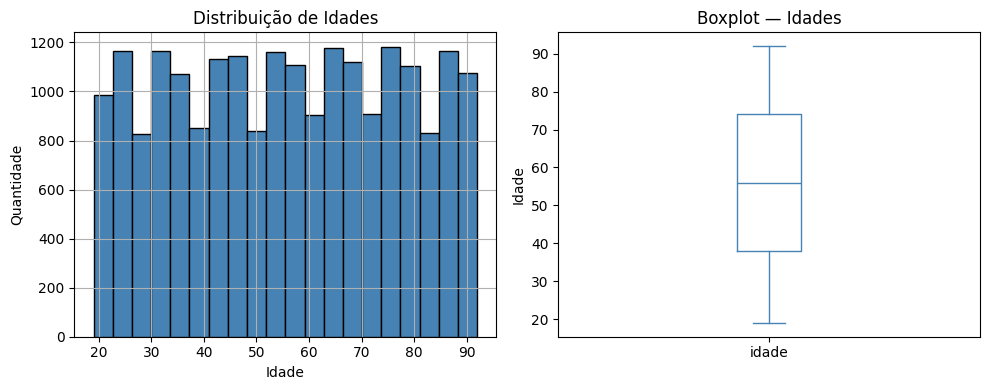

In [74]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['idade'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.subplot(1, 2, 2)
df['idade'].plot(kind='box', color='steelblue')
plt.title('Boxplot — Idades')
plt.ylabel('Idade')

plt.tight_layout()
plt.show()

In [75]:
print(f'=== RESUMO CAMADA PRATA ===')
print(f'Registros iniciais (Bronze) : {total_inicial}')
print(f'Registros finais   (Prata)  : {len(df)}')
print(f'Total removido              : {total_inicial - len(df)}')
print(f'\nNulos restantes:')
print(df.isnull().sum())

=== RESUMO CAMADA PRATA ===
Registros iniciais (Bronze) : 99999
Registros finais   (Prata)  : 20903
Total removido              : 79096

Nulos restantes:
id                     0
name                   0
email                  0
date_of_birth          0
signup_date            1
subscription_status    0
idade                  0
dtype: int64


In [76]:
output = os.path.join(PRATA_PATH, 'clean_data.csv')
df.to_csv(output, index=False)
print(f' Dados salvos em: {output}')
print(f'   Registros: {len(df)}')

 Dados salvos em: data/prata/clean_data.csv
   Registros: 20903


**Camada Ouro**

In [77]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_PATH  = '.'
PRATA_PATH = 'data/prata'
OURO_PATH  = 'data/ouro'

os.makedirs(OURO_PATH, exist_ok=True)
print('Configuração OK!')

Configuração OK!


In [78]:
df = pd.read_csv(os.path.join(PRATA_PATH, 'clean_data.csv'))
print(f'Registros carregados da Prata: {len(df)}')
print(f'Colunas: {list(df.columns)}')
df.head()

Registros carregados da Prata: 20903
Colunas: ['id', 'name', 'email', 'date_of_birth', 'signup_date', 'subscription_status', 'idade']


,id,name,email,date_of_birth,signup_date,subscription_status,idade
0,1,John Doe,john.doe@example.com,1985-01-15,2020-11-01,active,41
1,2,Jane Smith,jane.smith@example.com,1990-05-22,2019-06-17,active,35
2,3,Bob Johnson,bob.johnson@example,1977-03-30,2018-12-12,inactive,48
3,4,Alice Brown,alice.brown@example.com,1982-08-09,2021-01-05,active,43
4,5,Charlie Black,charlie.black@example.com,1988-11-23,NaN,inactive,37


In [79]:
def faixa_etaria(idade):
    """Categoriza a idade em faixas para análise demográfica."""
    if   idade <= 10: return '0 a 10'
    elif idade <= 20: return '11 a 20'
    elif idade <= 30: return '21 a 30'
    elif idade <= 40: return '31 a 40'
    elif idade <= 50: return '41 a 50'
    else:             return '51+'

# Testar a função
for idade in [5, 15, 25, 35, 45, 60]:
    print(f'Idade {idade:>3} → {faixa_etaria(idade)}')

Idade   5 → 0 a 10
Idade  15 → 11 a 20
Idade  25 → 21 a 30
Idade  35 → 31 a 40
Idade  45 → 41 a 50
Idade  60 → 51+


In [80]:
df['faixa_etaria'] = df['idade'].apply(faixa_etaria)

print(' Coluna faixa_etaria criada!')
print('\nDistribuição por faixa:')
print(df['faixa_etaria'].value_counts().sort_index())

 Coluna faixa_etaria criada!

Distribuição por faixa:
faixa_etaria
11 a 20      369
21 a 30     2912
31 a 40     2779
41 a 50     2818
51+        12025
Name: count, dtype: int64


In [81]:
if 'subscription_status' in df.columns:
    print('Antes:', df['subscription_status'].unique())
    df['subscription_status'] = df['subscription_status'].str.strip().str.lower()
    print('Depois:', df['subscription_status'].unique())
    print('\nContagem:')
    print(df['subscription_status'].value_counts())

Antes: ['active' 'inactive']
Depois: ['active' 'inactive']

Contagem:
subscription_status
active      10457
inactive    10446
Name: count, dtype: int64


In [82]:
# groupby + agg: forma eficiente de agregar grandes volumes de dados
agg_df = (
    df.groupby(['faixa_etaria', 'subscription_status'], as_index=False)
      .agg(total_usuarios=('name', 'count'))
      .sort_values(['faixa_etaria', 'subscription_status'])
)

print('=== Usuários por Faixa Etária e Status ===')
print(agg_df.to_string(index=False))

=== Usuários por Faixa Etária e Status ===
faixa_etaria subscription_status  total_usuarios
     11 a 20              active             192
     11 a 20            inactive             177
     21 a 30              active            1432
     21 a 30            inactive            1480
     31 a 40              active            1377
     31 a 40            inactive            1402
     41 a 50              active            1413
     41 a 50            inactive            1405
         51+              active            6043
         51+            inactive            5982


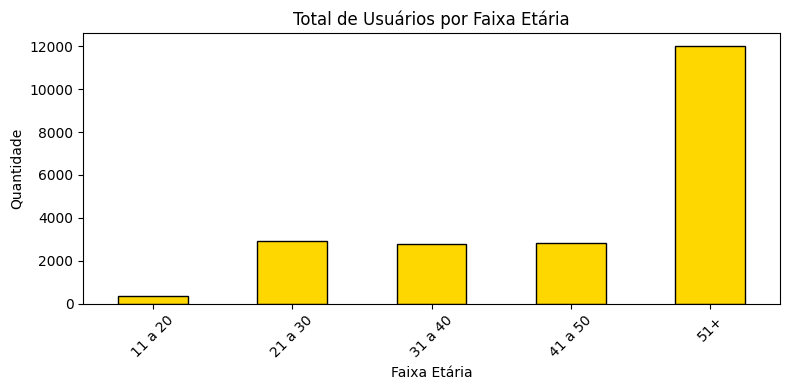

In [83]:
contagem = df['faixa_etaria'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
contagem.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Total de Usuários por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

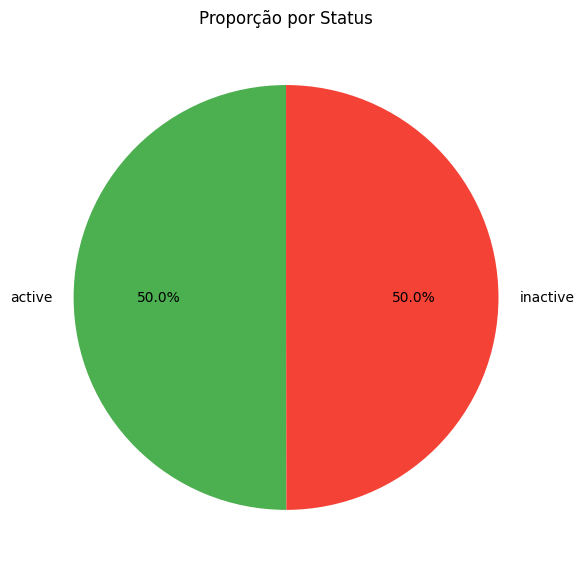

In [84]:
if 'subscription_status' in df.columns:
    contagem_status = df['subscription_status'].value_counts()

    plt.figure(figsize=(6, 6))
    contagem_status.plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90
    )
    plt.title('Proporção por Status')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

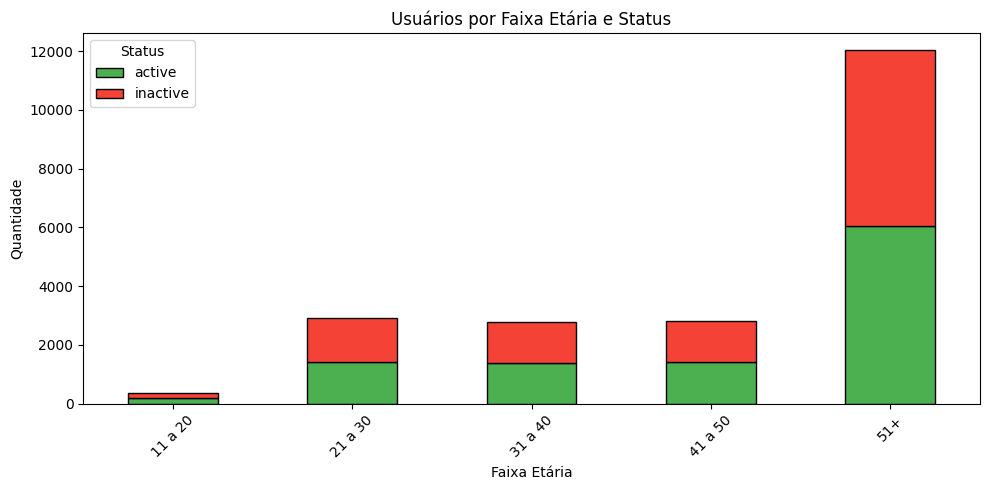

In [85]:
if 'subscription_status' in df.columns:
    pivot = agg_df.pivot(
        index='faixa_etaria',
        columns='subscription_status',
        values='total_usuarios'
    ).fillna(0)

    pivot.plot(kind='bar', stacked=True, figsize=(10, 5),
               color=['#4CAF50', '#F44336'], edgecolor='black')
    plt.title('Usuários por Faixa Etária e Status')
    plt.xlabel('Faixa Etária')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.legend(title='Status')
    plt.tight_layout()
    plt.show()

In [86]:
path_enriched = os.path.join(OURO_PATH, 'users_enriched.csv')
df.to_csv(path_enriched, index=False)
print(f' users_enriched.csv salvo — {len(df)} registros')

 users_enriched.csv salvo — 20903 registros


In [87]:
path_agg = os.path.join(OURO_PATH, 'users_by_age_and_status.csv')
agg_df.to_csv(path_agg, index=False)
print(f' users_by_age_and_status.csv salvo — {len(agg_df)} linhas')

print('\n=== PIPELINE CONCLUÍDO COM SUCESSO! ===')
print('Bronze → Prata → Ouro ')

 users_by_age_and_status.csv salvo — 10 linhas

=== PIPELINE CONCLUÍDO COM SUCESSO! ===
Bronze → Prata → Ouro 


**DAG Airflow**

In [88]:
import os

pastas = [
    'data/bronze',
    'data/prata',
    'data/ouro',
    'dags',
    'logs',
    'plugins'
]

for pasta in pastas:
    os.makedirs(pasta, exist_ok=True)
    print(f' {pasta}')

print('\n Estrutura de pastas pronta!')

 data/bronze
 data/prata
 data/ouro
 dags
 logs
 plugins

 Estrutura de pastas pronta!


In [89]:
import pandas as pd
import sys

print(f'Python : {sys.version}')
print(f'Pandas : {pd.__version__}')
print('\n Ambiente OK!')

Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas : 2.2.2

 Ambiente OK!


In [90]:
dag_code = '''
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta
import pandas as pd
import os
import re

BASE_PATH   = '/opt/airflow/data'
BRONZE_PATH = os.path.join(BASE_PATH, 'bronze')
PRATA_PATH  = os.path.join(BASE_PATH, 'prata')
OURO_PATH   = os.path.join(BASE_PATH, 'ouro')
RAW_FILE    = os.path.join(BASE_PATH, 'raw_data.csv')

def upload_raw_data_to_bronze():
    os.makedirs(BRONZE_PATH, exist_ok=True)
    if not os.path.exists(RAW_FILE):
        raise FileNotFoundError(f'raw_data.csv nao encontrado em: {RAW_FILE}')
    df = pd.read_csv(RAW_FILE)
    print(f'[BRONZE] Registros carregados: {len(df)}')
    df.to_csv(os.path.join(BRONZE_PATH, 'raw_data.csv'), index=False)

def process_bronze_to_silver():
    os.makedirs(PRATA_PATH, exist_ok=True)
    df = pd.read_csv(os.path.join(BRONZE_PATH, 'raw_data.csv'))
    cols = [c for c in ['name','email','date_of_birth'] if c in df.columns]
    df = df.dropna(subset=cols)
    df = df[df['email'].apply(lambda e: isinstance(e,str) and '@' in e)]
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
    df = df.dropna(subset=['date_of_birth'])
    hoje = pd.Timestamp.today()
    df['idade'] = df['date_of_birth'].apply(lambda d: (hoje - d).days // 365)
    df.to_csv(os.path.join(PRATA_PATH, 'clean_data.csv'), index=False)

def process_silver_to_gold():
    os.makedirs(OURO_PATH, exist_ok=True)
    df = pd.read_csv(os.path.join(PRATA_PATH, 'clean_data.csv'))
    def faixa_etaria(idade):
        if   idade <= 10: return '0 a 10'
        elif idade <= 20: return '11 a 20'
        elif idade <= 30: return '21 a 30'
        elif idade <= 40: return '31 a 40'
        elif idade <= 50: return '41 a 50'
        else:             return '51+'
    df['faixa_etaria'] = df['idade'].apply(faixa_etaria)
    df['subscription_status'] = df['subscription_status'].str.strip().str.lower()
    agg_df = df.groupby(['faixa_etaria','subscription_status'], as_index=False).agg(
        total_usuarios=('name','count')).sort_values(['faixa_etaria','subscription_status'])
    df.to_csv(os.path.join(OURO_PATH, 'users_enriched.csv'), index=False)
    agg_df.to_csv(os.path.join(OURO_PATH, 'users_by_age_and_status.csv'), index=False)

with DAG(
    dag_id='pipeline_dncinsight',
    default_args={'owner': 'dncinsight', 'retries': 1, 'retry_delay': timedelta(minutes=1)},
    description='Pipeline Bronze -> Prata -> Ouro — DncInsight Solutions',
    schedule_interval=None,
    start_date=datetime(2024, 1, 1),
    catchup=False,
    tags=['dncinsight', 'data-pipeline'],
) as dag:
    t1_bronze = PythonOperator(task_id='upload_raw_data_to_bronze', python_callable=upload_raw_data_to_bronze)
    t2_prata  = PythonOperator(task_id='process_bronze_to_silver',  python_callable=process_bronze_to_silver)
    t3_ouro   = PythonOperator(task_id='process_silver_to_gold',    python_callable=process_silver_to_gold)
    t1_bronze >> t2_prata >> t3_ouro
'''

print(dag_code)


from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta
import pandas as pd
import os
import re

BASE_PATH   = '/opt/airflow/data'
BRONZE_PATH = os.path.join(BASE_PATH, 'bronze')
PRATA_PATH  = os.path.join(BASE_PATH, 'prata')
OURO_PATH   = os.path.join(BASE_PATH, 'ouro')
RAW_FILE    = os.path.join(BASE_PATH, 'raw_data.csv')

def upload_raw_data_to_bronze():
    os.makedirs(BRONZE_PATH, exist_ok=True)
    if not os.path.exists(RAW_FILE):
        raise FileNotFoundError(f'raw_data.csv nao encontrado em: {RAW_FILE}')
    df = pd.read_csv(RAW_FILE)
    print(f'[BRONZE] Registros carregados: {len(df)}')
    df.to_csv(os.path.join(BRONZE_PATH, 'raw_data.csv'), index=False)

def process_bronze_to_silver():
    os.makedirs(PRATA_PATH, exist_ok=True)
    df = pd.read_csv(os.path.join(BRONZE_PATH, 'raw_data.csv'))
    cols = [c for c in ['name','email','date_of_birth'] if c in df.columns]
    df = df.dropna(subset=cols)
    df = df[df

In [91]:
# Verificar arquivos gerados após execução do DAG

camadas = {
    ' Bronze': ('data/bronze', ['raw_data.csv']),
    ' Prata':  ('data/prata',  ['clean_data.csv']),
    ' Ouro':   ('data/ouro',   ['users_enriched.csv',
                                   'users_by_age_and_status.csv']),
}

for camada, (pasta, arquivos) in camadas.items():
    print(f'\n{camada} — {pasta}/')
    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)
        if os.path.exists(caminho):
            df_check = pd.read_csv(caminho)
            print(f'   {arquivo} — {len(df_check)} registros')
        else:
            print(f'   {arquivo} — não encontrado')


 Bronze — data/bronze/
   raw_data.csv — 99999 registros

 Prata — data/prata/
   clean_data.csv — 20903 registros

 Ouro — data/ouro/
   users_enriched.csv — 20903 registros
   users_by_age_and_status.csv — 10 registros


In [92]:
# Preview do resultado final
ouro_path = 'data/ouro/users_by_age_and_status.csv'

if os.path.exists(ouro_path):
    df_resultado = pd.read_csv(ouro_path)
    print('=== RESULTADO FINAL — Usuários por Faixa Etária e Status ===\n')
    print(df_resultado.to_string(index=False))
else:
    print('Execute o DAG no Airflow primeiro!')

=== RESULTADO FINAL — Usuários por Faixa Etária e Status ===

faixa_etaria subscription_status  total_usuarios
     11 a 20              active             192
     11 a 20            inactive             177
     21 a 30              active            1432
     21 a 30            inactive            1480
     31 a 40              active            1377
     31 a 40            inactive            1402
     41 a 50              active            1413
     41 a 50            inactive            1405
         51+              active            6043
         51+            inactive            5982
